In [64]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline

training_set = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.5%20EDA/data/titanic.csv')

training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


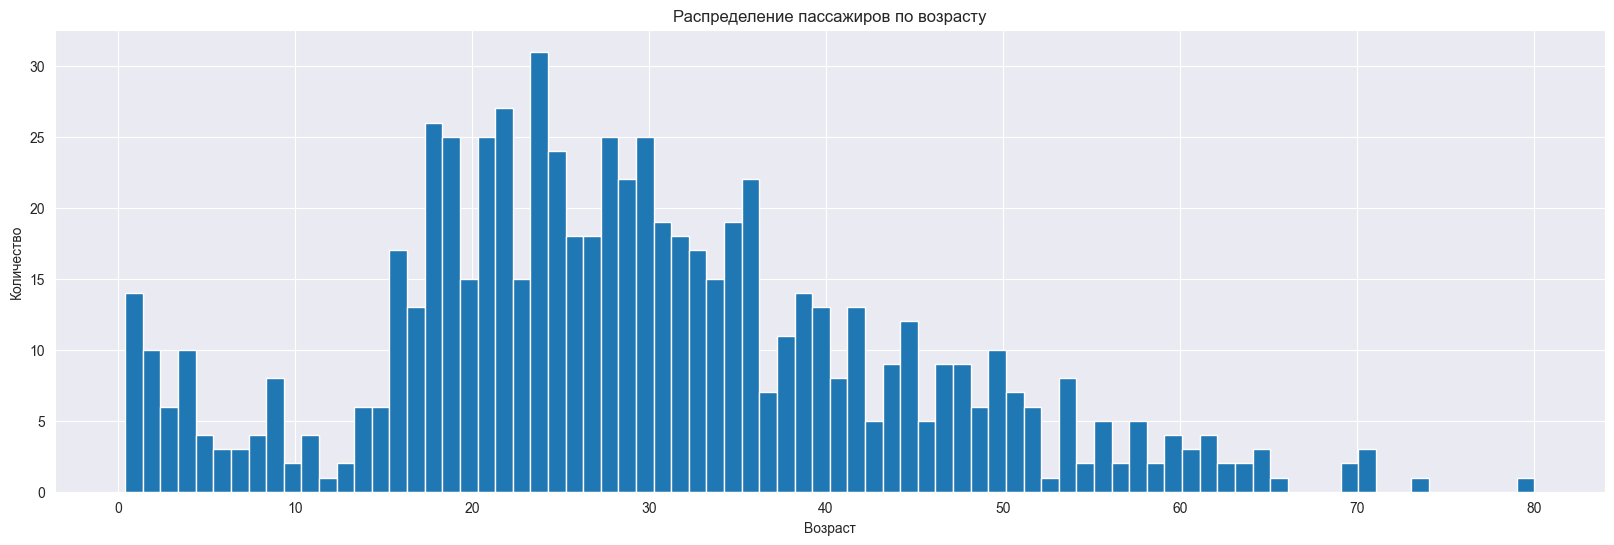

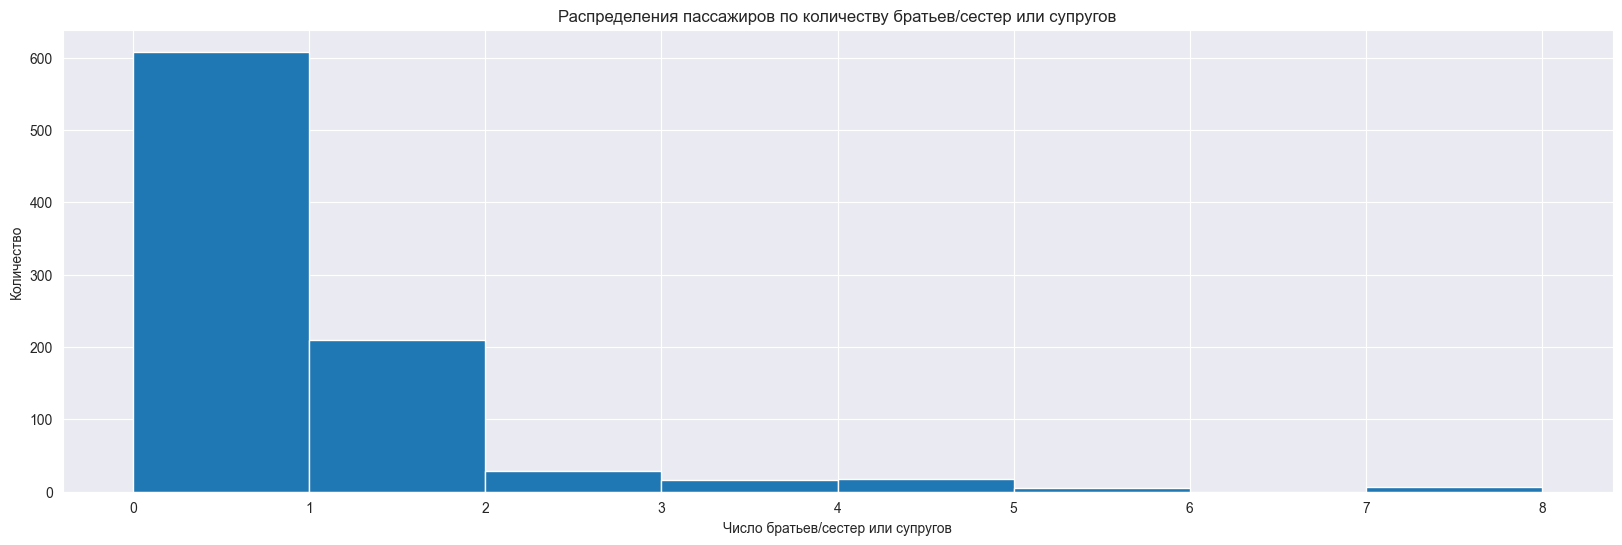

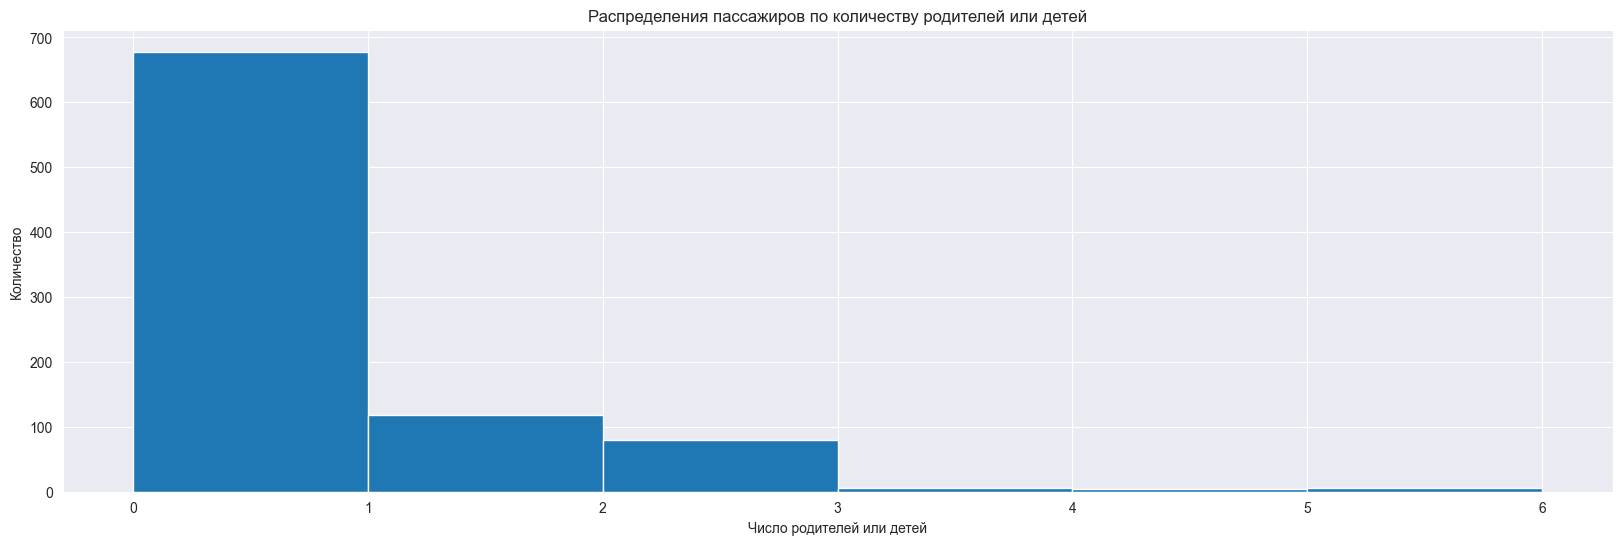

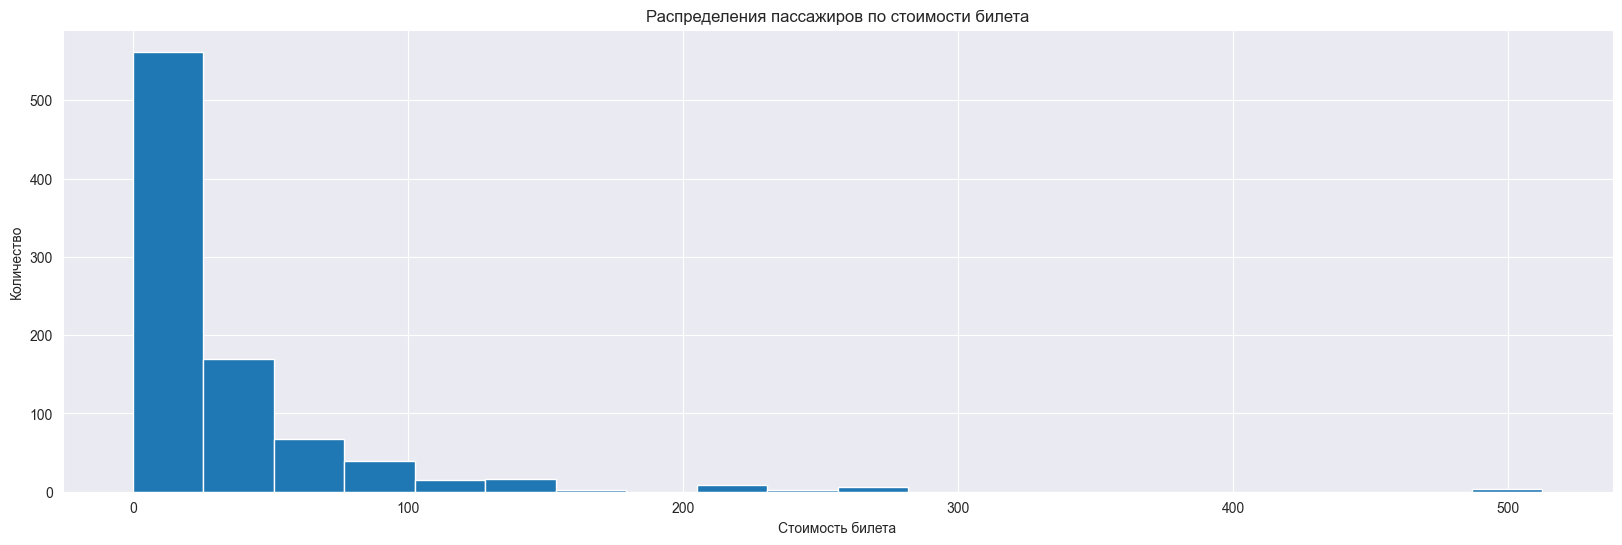

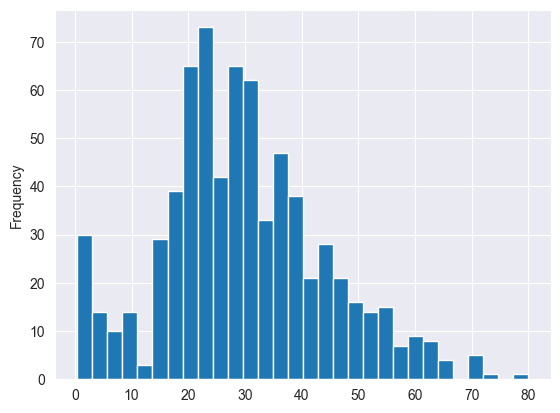

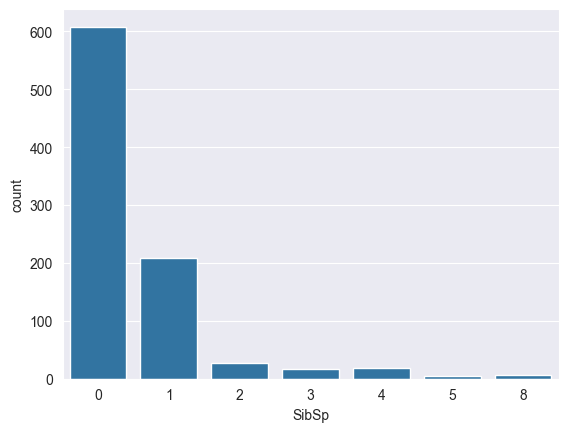

<Axes: >

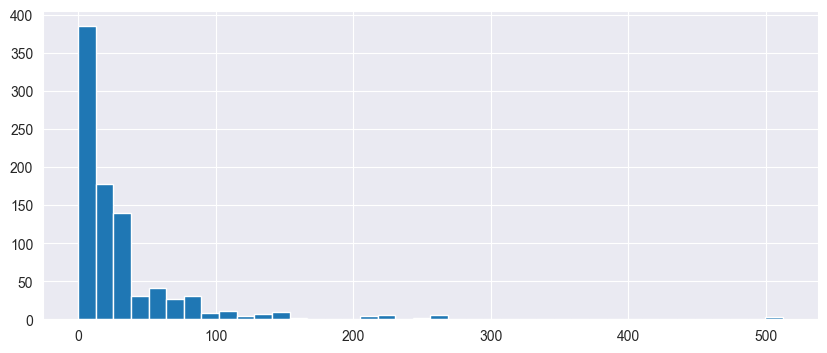

In [65]:
def custom_hist(training_set, title, xlabel, ylabel='Количество', bins=None):
    figsize = (20, 6)
    plt.figure(figsize=figsize)
    plt.grid(True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.hist(training_set, training_set.max().astype(int) if bins is None else bins)
    plt.show()

custom_hist(training_set['Age'], 'Распределение пассажиров по возрасту', 'Возраст')
custom_hist(training_set["SibSp"], 'Распределения пассажиров по количеству братьев/сестер или супругов',
  'Число братьев/сестер или супругов')
custom_hist(training_set["Parch"], 'Распределения пассажиров по количеству родителей или детей',
  'Число родителей или детей')
custom_hist(training_set["Fare"], 'Распределения пассажиров по стоимости билета',
  'Стоимость билета', bins=20)
training_set['Age'].plot.hist(bins=30)
plt.show()
sns.countplot(x='SibSp', data=training_set)
plt.show()
training_set['Fare'].hist(bins=40, figsize=(10,4))

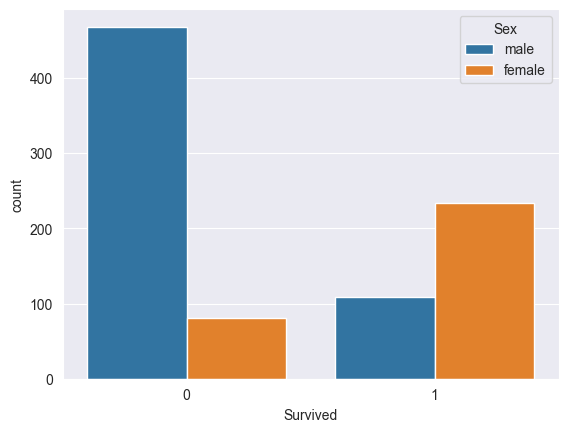

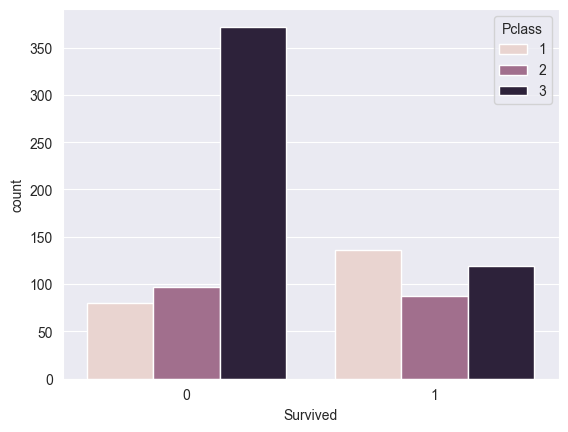

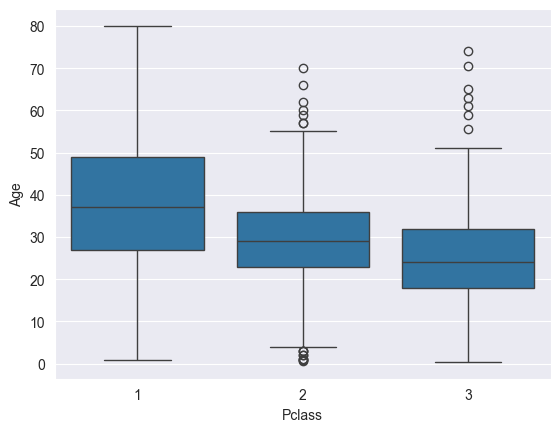

In [66]:
sns.countplot(x='Survived', data=training_set, hue='Sex')
plt.show()
sns.countplot(x='Survived', data=training_set, hue='Pclass')
plt.show()
sns.boxplot(x='Pclass', y='Age', data=training_set)
plt.show()

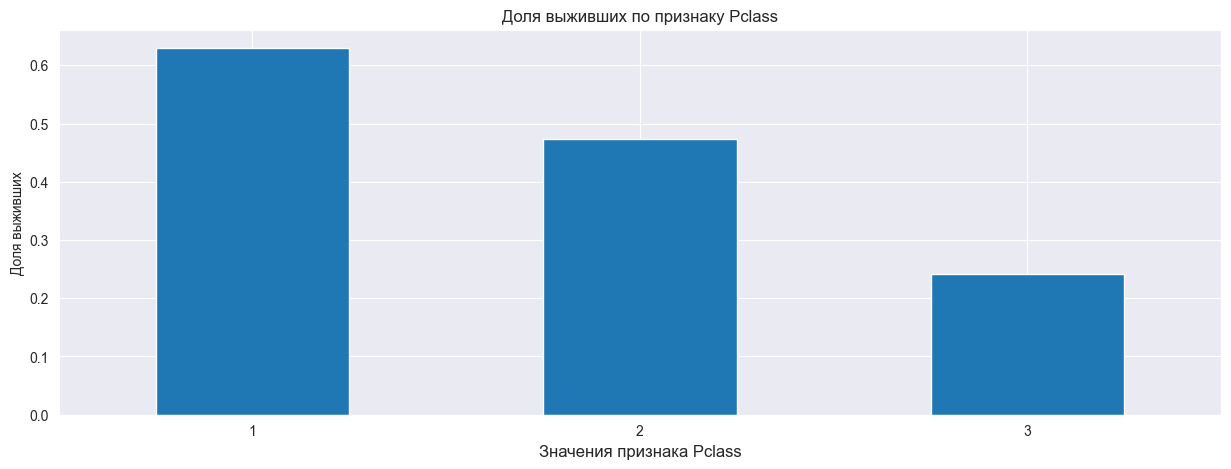

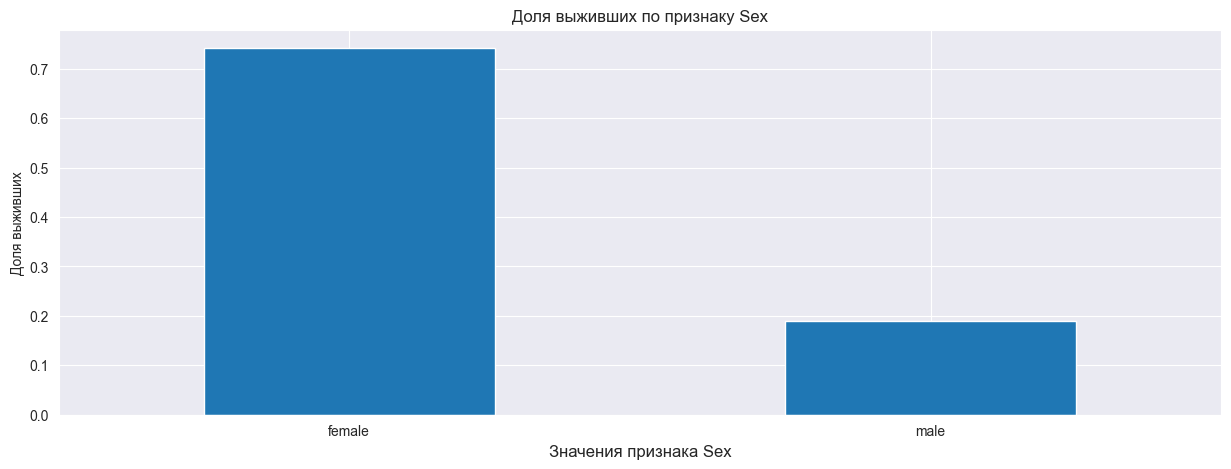

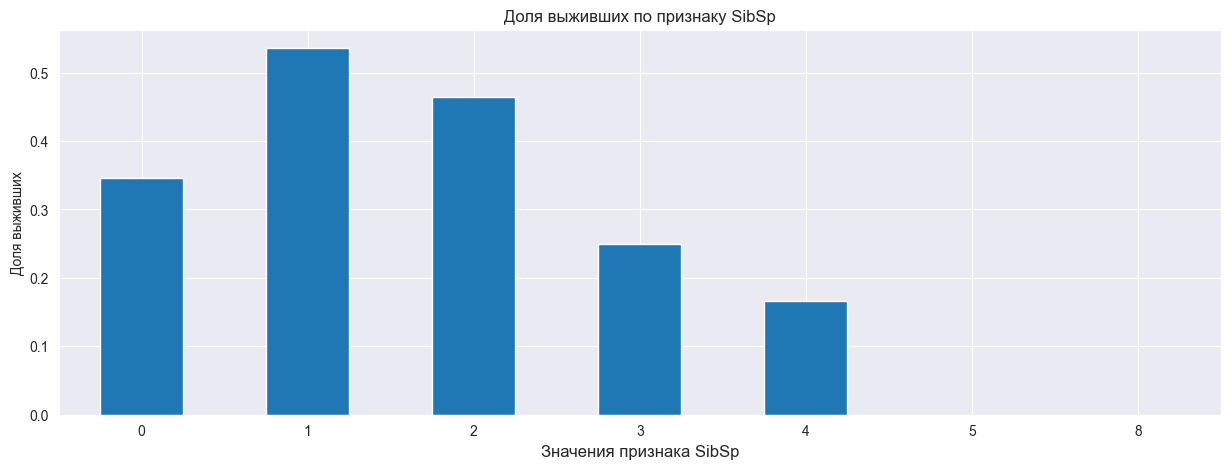

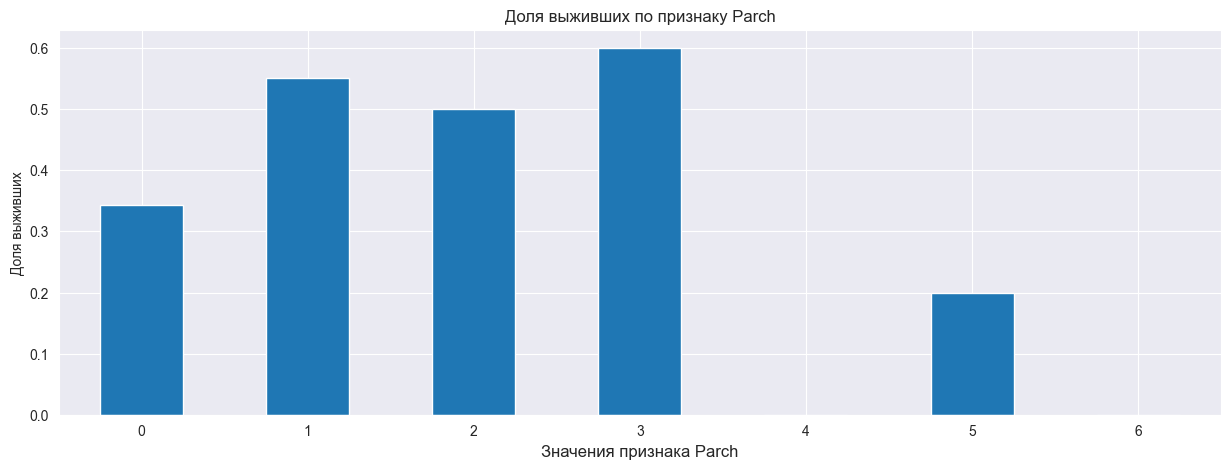

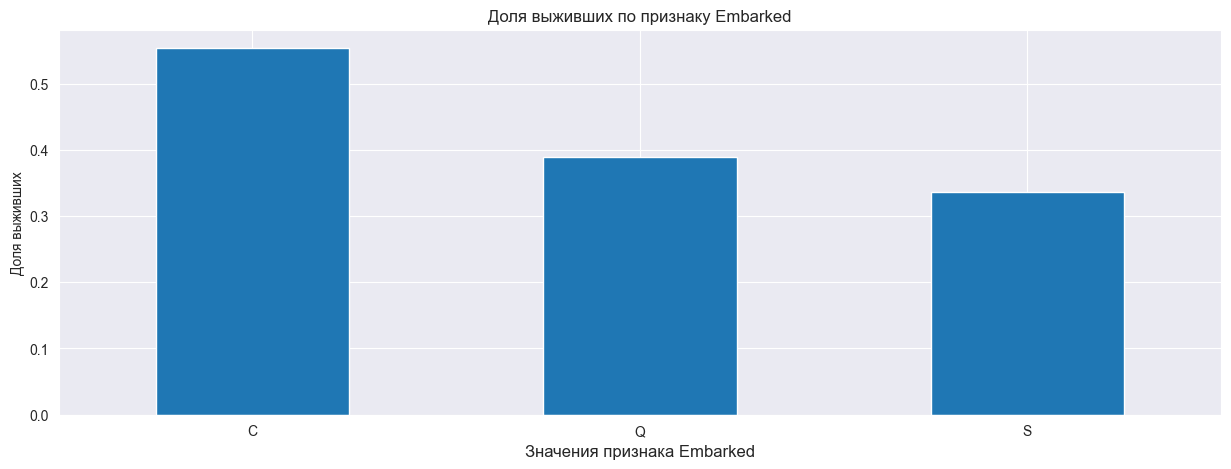

In [67]:
columns_to_look = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
for column in columns_to_look:
    pivot = training_set.pivot_table(index=column, values='Survived', aggfunc='mean')

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.set_title(f'Доля выживших по признаку {column}')
    ax.set_ylabel('Доля выживших')
    ax.set_xlabel(column)

    for cnt in range(pivot.shape[0]):
        value = pivot.iloc[cnt].values[0]

    pivot.plot(kind='bar', rot=0, grid=True, legend=False, ax=ax)
    ax.set_xlabel(f'Значения признака {column}', fontdict={'size': 12})
    plt.show()

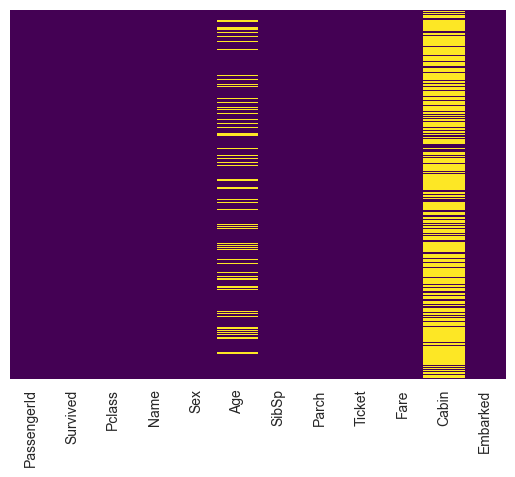

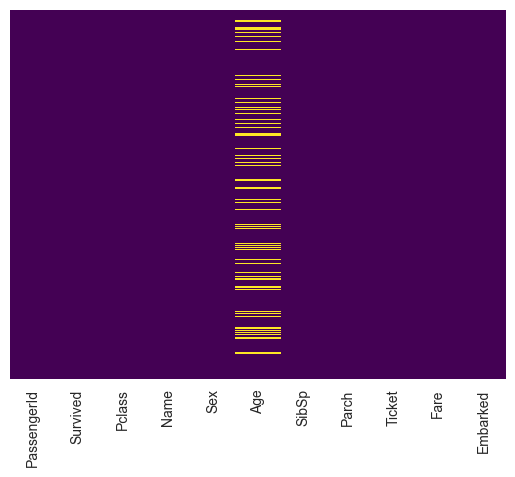

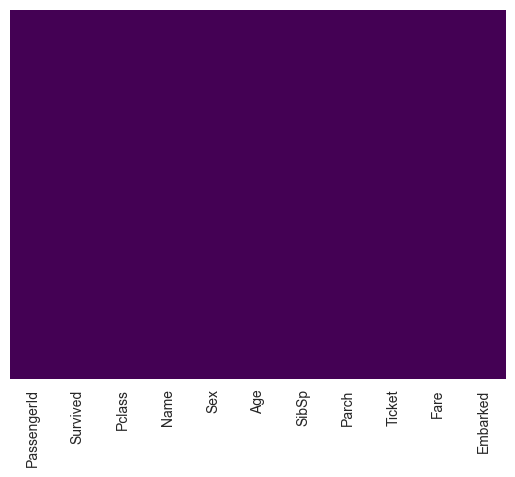

In [68]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()
training_set.drop('Cabin', axis=1, inplace=True)
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()
training_set.dropna(inplace=True)
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

In [69]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

le = LabelEncoder()
enc_le = le.fit_transform(training_set['Sex'])

print(le.inverse_transform([0, 1]))

ohe = OneHotEncoder()
enc_ohe = ohe.fit_transform(training_set[['Embarked']])

sex = pd.get_dummies(training_set['Sex'], drop_first=True)
embark = pd.get_dummies(training_set['Embarked'], drop_first=True)

training_set = pd.concat([training_set, sex, embark], axis=1)

training_set.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

training_set.head()

['female' 'male']


,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(training_set.drop('Survived', axis=1), training_set['Survived'], test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = model.score(X_test, y_test)
print(score)

training_set_celan = training_set.copy()

0.7972027972027972


Доля выживших 0.3838383838383838
Выживание по полу Sex
female    233
male      109
Name: count, dtype: int64

Пассажиров в классе Pclass
3    491
1    216
2    184
Name: count, dtype: int64


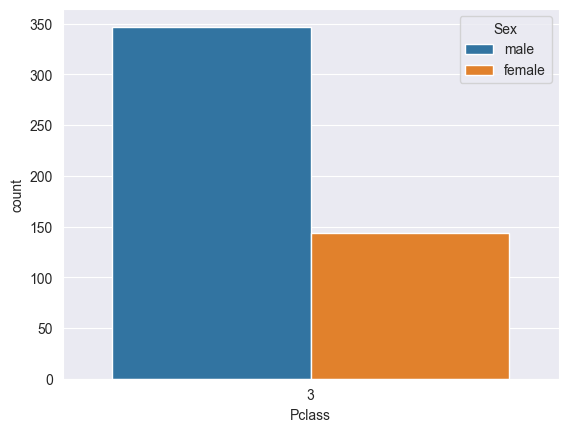

In [71]:
training_set = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.5%20EDA/data/titanic.csv')

print('Доля выживших', training_set['Survived'].mean())
print('Выживание по полу', training_set[training_set['Survived'] == 1]['Sex'].value_counts())
print()
print('Пассажиров в классе', training_set['Pclass'].value_counts())
sns.countplot(data=training_set[training_set['Pclass'] == 3], x='Pclass', hue='Sex')
plt.show()

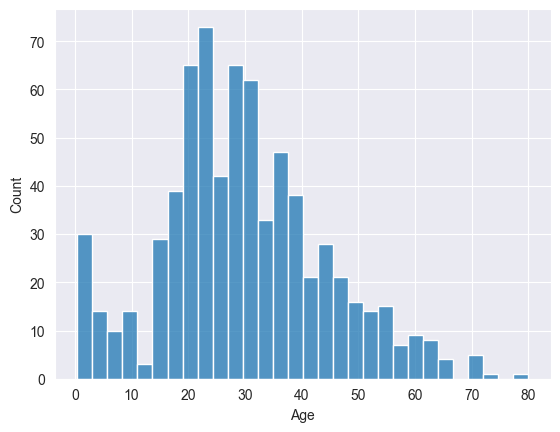

           Age      Fare
Age   1.000000  0.096067
Fare  0.096067  1.000000


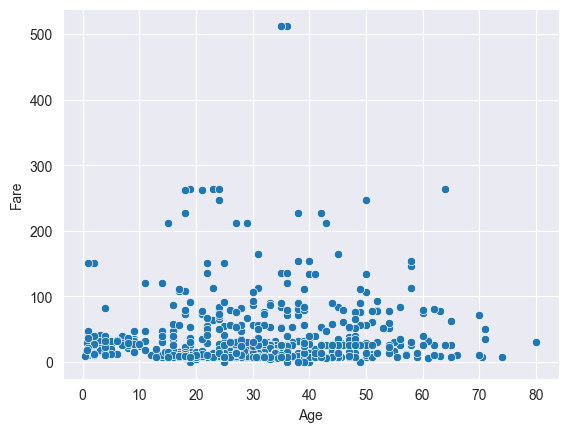

In [72]:
sns.histplot(training_set['Age'].dropna(), bins=30)
plt.show()

corr = training_set[['Age', 'Fare']].corr()
print(corr)

sns.scatterplot(data=training_set, x='Age', y='Fare')
plt.show()

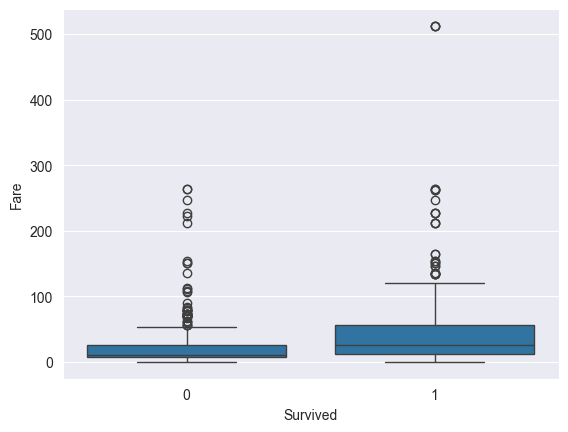

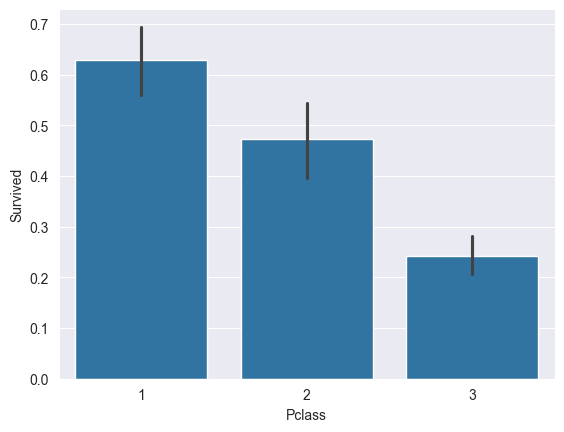

In [73]:
sns.boxplot(data=training_set, x='Survived', y='Fare')
plt.show()

sns.barplot(data=training_set, x='Pclass', y='Survived')
plt.show()

In [74]:
fare_stats = training_set.groupby('Embarked')['Fare'].agg(['min', 'mean', 'max'])
print(fare_stats)

             min       mean       max
Embarked                             
C         4.0125  59.954144  512.3292
Q         6.7500  13.276030   90.0000
S         0.0000  27.079812  263.0000


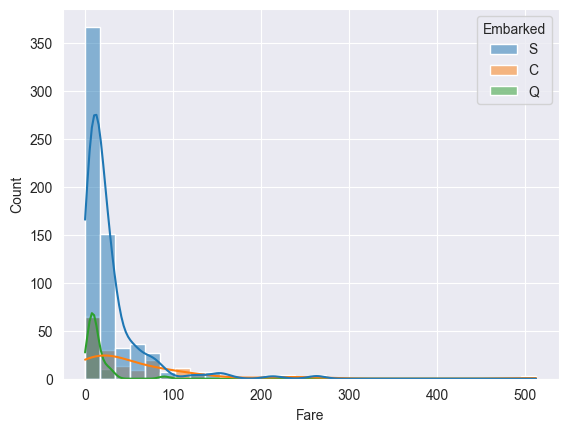

In [75]:
sns.histplot(data=training_set, x='Fare', hue='Embarked', bins=30, kde=True)
plt.show()

In [76]:
dataset_size = len(training_set)
real_total = 2224

print("Доля выборки:", dataset_size / real_total)

Доля выборки: 0.4006294964028777


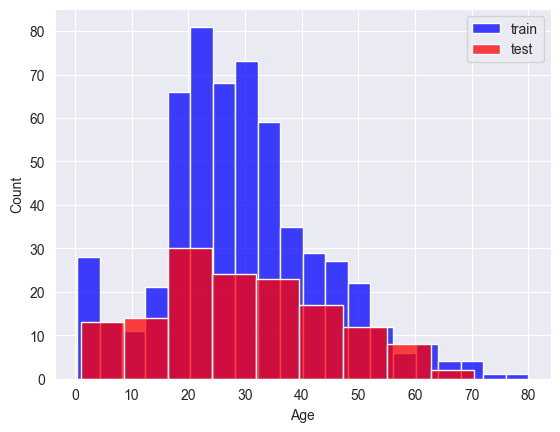

In [77]:
train, test = train_test_split(training_set_celan, test_size=0.2, random_state=42)

sns.histplot(train['Age'], color='blue', label='train')
sns.histplot(test['Age'], color='red', label='test')
plt.legend()
plt.show()

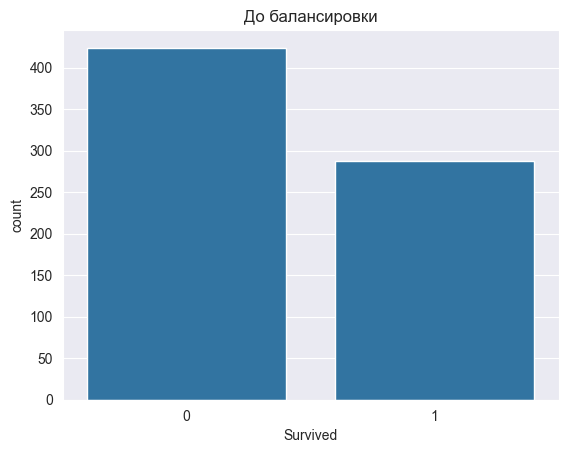

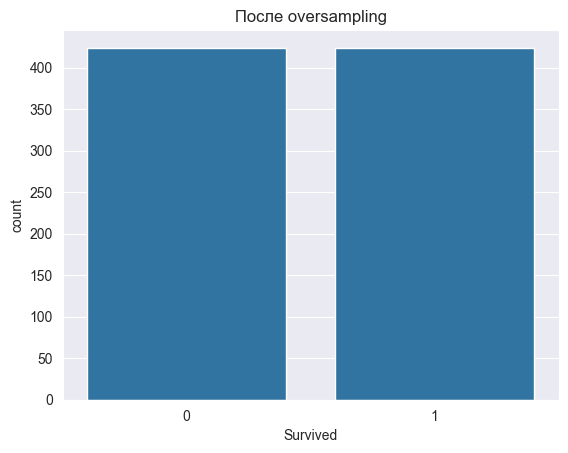

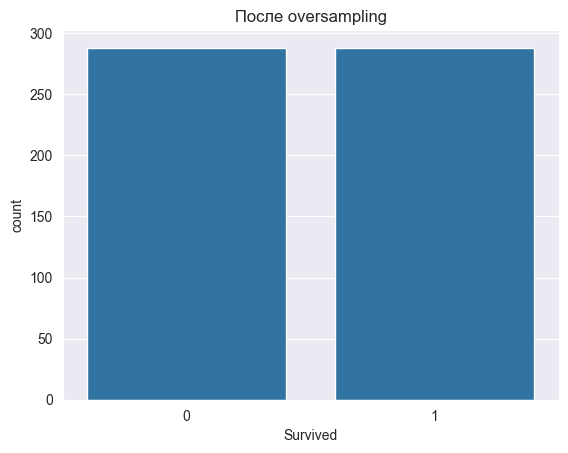

In [78]:
majority = training_set_celan[training_set_celan['Survived'] == 0]
minority = training_set_celan[training_set_celan['Survived'] == 1]

majority_downsampled = majority.sample(len(minority), random_state=42)
df_under = pd.concat([majority_downsampled, minority])
minority_upsampled = minority.sample(len(majority), replace=True, random_state=42)
df_over = pd.concat([majority, minority_upsampled])


sns.countplot(data=training_set_celan, x='Survived')
plt.title('До балансировки')
plt.show()

sns.countplot(data=df_over, x='Survived')
plt.title('После oversampling')
plt.show()
sns.countplot(data=df_under, x='Survived')
plt.title('После oversampling')
plt.show()

In [80]:
print(score)

X = df_over.drop('Survived', axis=1)
y = df_over['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(model.score(X_test, y_test))

X = df_under.drop('Survived', axis=1)
y = df_under['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(model.score(X_test, y_test))


0.7972027972027972
0.788235294117647
0.8189655172413793


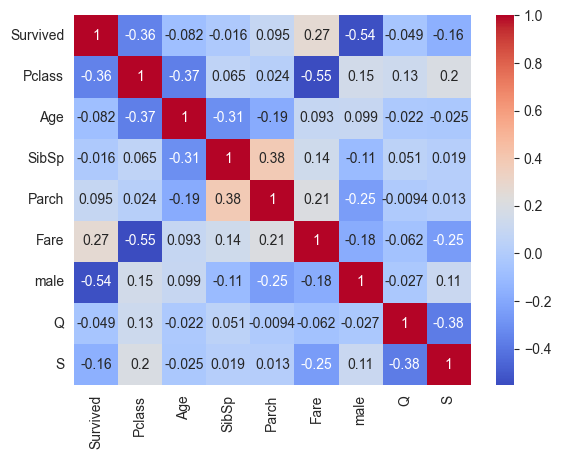

In [81]:
sns.heatmap(training_set_celan.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

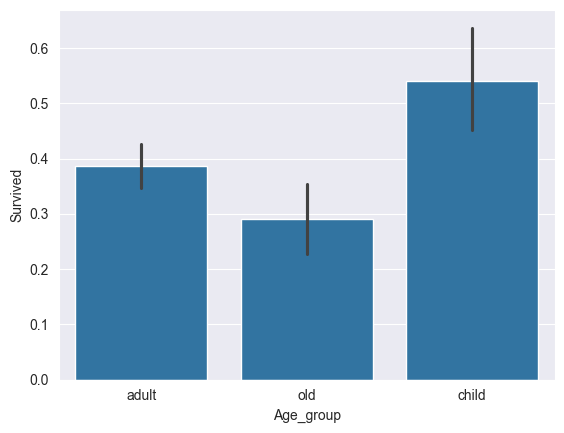

In [84]:
def age_group(age):
    if age < 18:
        return 'child'
    elif age < 60:
        return 'adult'
    else:
        return 'old'

training_set['Age_group'] = training_set['Age'].apply(age_group)
sns.barplot(data=training_set, x='Age_group', y='Survived')
plt.show()